In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


In [ ]:
import pandas as pd

# 1) parquet 로드
sha_df = pd.read_parquet("../sha_df.parquet")

# ✅ 컬럼명 목록 출력
print(sha_df.columns)



Index(['고객ID', '기준년월', '해지여부', '연령대', '가입기간', '총사용일수', '만료잔여기간', '약정만료일',
       '구형장비여부', '최근1달_셋톱장애경험', '최근1달_민원접수', '최근1달_해지방어', '유튜브_사용여부',
       '넷플릭스_사용여부', '월평균시청시간', '재택비율', '마지막시청_경과일', '키즈시청건수'],
      dtype='object')


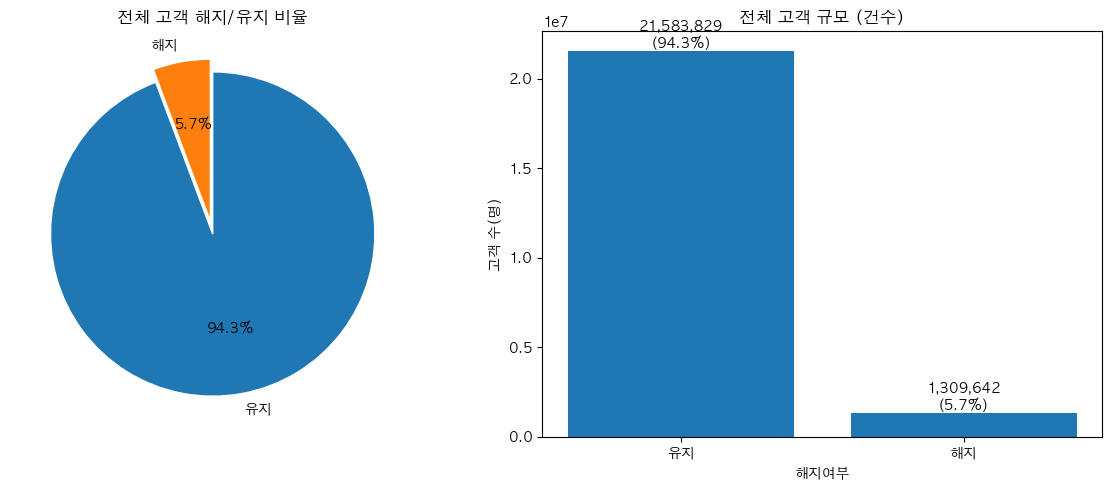

유지: 21,583,829명 (94.3%)
해지: 1,309,642명 (5.7%)
전체: 22,893,471명


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) parquet 로드
sha_df = pd.read_parquet("sha_df.parquet")

CANCEL_COL = "해지여부"
KEEP_VAL   = "유지"
CANCEL_VAL = "해지"

# 2) 공백/결측 대비 정리
tmp = sha_df.copy()
tmp[CANCEL_COL] = tmp[CANCEL_COL].astype(str).str.strip()

# 3) 집계
counts = tmp[CANCEL_COL].value_counts(dropna=False)

n_keep   = int(counts.get(KEEP_VAL, 0))
n_cancel = int(counts.get(CANCEL_VAL, 0))
n_total  = n_keep + n_cancel


keep_rate   = n_keep / n_total
cancel_rate = n_cancel / n_total

# 4) 시각화: 파이 + 막대 (슬라이드 형태)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (A) 파이차트
axes[0].pie(
    [keep_rate, cancel_rate],
    labels=["유지", "해지"],
    autopct="%.1f%%",
    startangle=90,
    counterclock=False,
    explode=(0, 0.08),
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
axes[0].set_title("전체 고객 해지/유지 비율")

# (B) 막대그래프
x = ["유지", "해지"]
y = [n_keep, n_cancel]
bars = axes[1].bar(x, y)

axes[1].set_title("전체 고객 규모 (건수)")
axes[1].set_xlabel("해지여부")
axes[1].set_ylabel("고객 수(명)")

for bar, v in zip(bars, y):
    pct = (v / n_total) * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# 5) 숫자 출력(보고서용)
print(f"유지: {n_keep:,}명 ({keep_rate:.1%})")
print(f"해지: {n_cancel:,}명 ({cancel_rate:.1%})")
print(f"전체: {n_total:,}명")


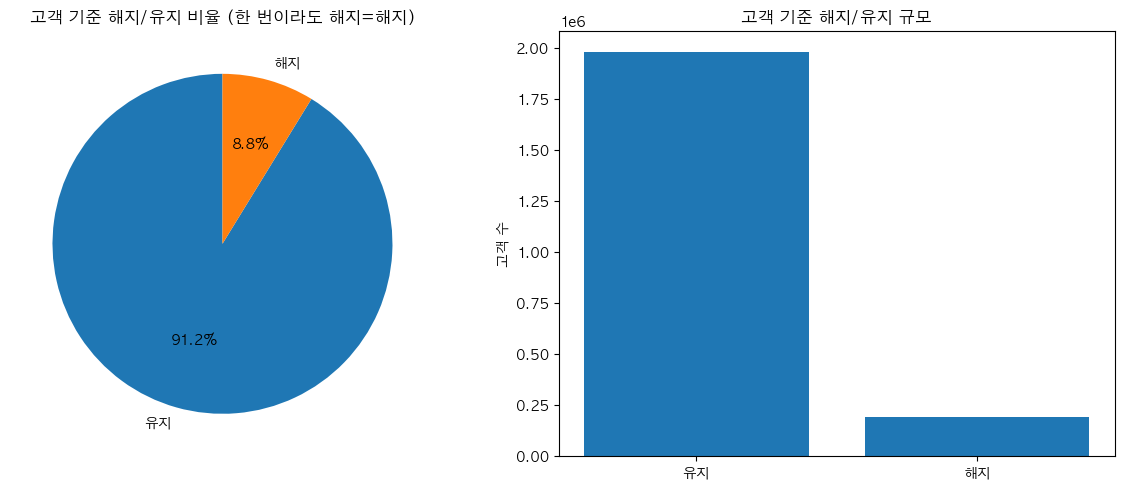

고객 수(총): 2175327
유지: 1984651
해지: 190676


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 데이터 로드
df = pd.read_parquet("sha_df.parquet")

# 2) 정리 (공백 제거)
df["해지여부"] = df["해지여부"].astype(str).str.strip()

# 3) 고객 1명당 1행 만들기: "한 번이라도 해지"면 해지로 집계
#    (해지여부: 유지/해지)
cust = (
    df.groupby("고객ID", as_index=False)
      .agg(
          해지여부=("해지여부", lambda x: "해지" if (x == "해지").any() else "유지"),
          기준년월=("기준년월", "max")  # 참고용(마지막 관측월)
      )
)

# 4) 전체 해지/유지 집계
cnt = cust["해지여부"].value_counts()
labels = ["유지", "해지"]
vals = [cnt.get("유지", 0), cnt.get("해지", 0)]

# 5) 시각화 (파이 + 막대)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(vals, labels=labels, autopct="%.1f%%", startangle=90)
ax[0].set_title("고객 기준 해지/유지 비율 (한 번이라도 해지=해지)")

ax[1].bar(labels, vals)
ax[1].set_title("고객 기준 해지/유지 규모")
ax[1].set_ylabel("고객 수")

plt.tight_layout()
plt.show()

# 6) 숫자 출력(보고서용)
print("고객 수(총):", len(cust))
print("유지:", vals[0])
print("해지:", vals[1])


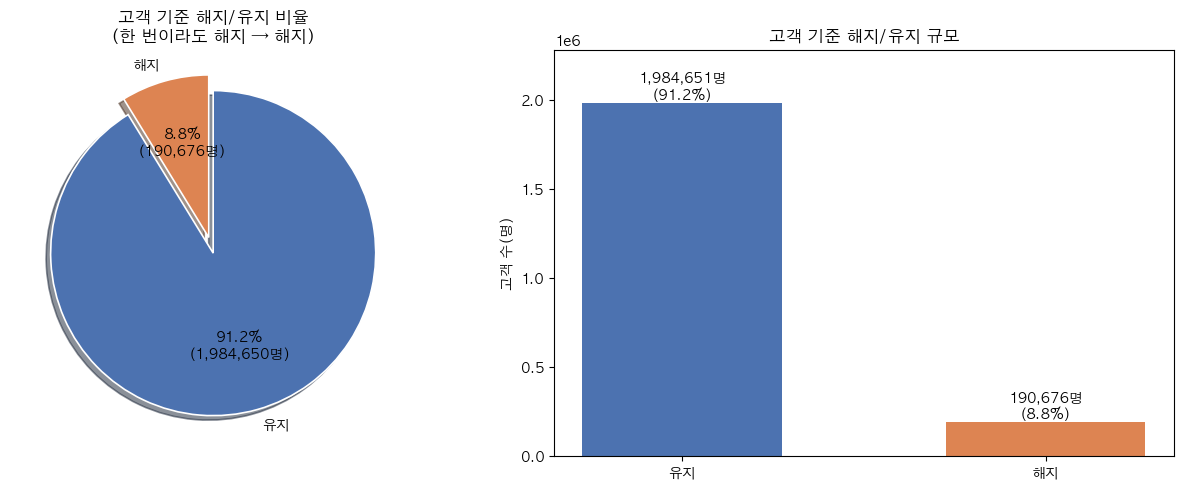

전체 고객 수: 2,175,327명
유지 고객: 1,984,651명 (91.2%)
해지 고객: 190,676명 (8.8%)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 데이터 로드
df = pd.read_parquet("sha_df.parquet")

# 2) 전처리
df["해지여부"] = df["해지여부"].astype(str).str.strip()

# 3) 고객 단위 집계 (한 번이라도 해지 → 해지)
cust = (
    df.groupby("고객ID", as_index=False)
      .agg(
          해지여부=("해지여부", lambda x: "해지" if (x == "해지").any() else "유지")
      )
)

# 4) 집계
cnt = cust["해지여부"].value_counts()
labels = ["유지", "해지"]
values = [cnt.get("유지", 0), cnt.get("해지", 0)]
total = sum(values)

# 색상 지정 (발표용)
colors = ["#4C72B0", "#DD8452"]  # 파랑=유지, 주황=해지

# 5) 시각화
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------
# (1) 파이차트
# -------------------------
ax[0].pie(
    values,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(p*total/100):,}명)",
    startangle=90,
    counterclock=False,
    explode=(0, 0.1),          # 해지만 강조
    shadow=True,               # 입체감
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
ax[0].set_title("고객 기준 해지/유지 비율\n(한 번이라도 해지 → 해지)", fontsize=12)

# -------------------------
# (2) 막대그래프
# -------------------------
bars = ax[1].bar(labels, values, color=colors, width=0.55)

ax[1].set_title("고객 기준 해지/유지 규모", fontsize=12)
ax[1].set_ylabel("고객 수(명)")
ax[1].set_ylim(0, max(values) * 1.15)

# 막대 위에 숫자 표시
for bar, v in zip(bars, values):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v:,}명\n({v/total*100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# 6) 텍스트 출력 (노션/보고서용)
print(f"전체 고객 수: {total:,}명")
print(f"유지 고객: {values[0]:,}명 ({values[0]/total:.1%})")
print(f"해지 고객: {values[1]:,}명 ({values[1]/total:.1%})")


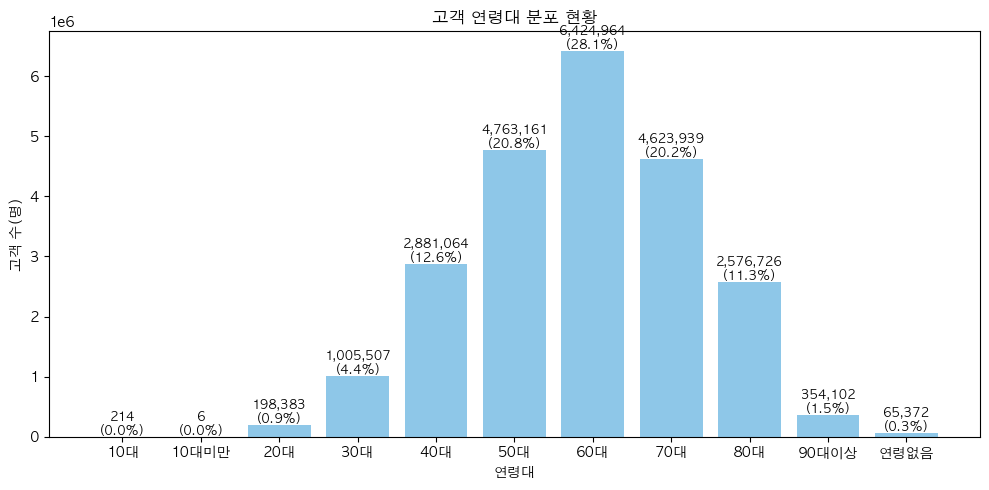

30대 이하 비중: 5.3%
40대 이상 비중: 94.5%


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 데이터 로드
# 2) 연령대 컬럼
AGE_COL = "연령대"

# 3) 연령대 분포 계산
age_cnt = df[AGE_COL].value_counts().sort_index()
total = age_cnt.sum()

# 비율(%)
age_rate = age_cnt / total * 100

# 4) 막대그래프 (연령대 분포)
plt.figure(figsize=(10, 5))
bars = plt.bar(age_cnt.index, age_cnt.values, color="#8EC7E8")

plt.title("고객 연령대 분포 현황")
plt.xlabel("연령대")
plt.ylabel("고객 수(명)")

# 막대 위에 건수 + 비율 표시
for bar, cnt, rate in zip(bars, age_cnt.values, age_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{cnt:,}\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# 5) 30대 이하 / 40대 이상 비중 계산
under_30 = age_cnt.loc[["10대미만", "10대", "20대", "30대"]].sum()
over_40  = age_cnt.loc[["40대", "50대", "60대", "70대", "80대", "90대이상"]].sum()

print(f"30대 이하 비중: {under_30/total*100:.1f}%")
print(f"40대 이상 비중: {over_40/total*100:.1f}%")
